# Goodreads Book Data Analysis - M3: Complete Implementation 

### Q1: Association Rule Mining — Book Attributes and Reader Engagement

**Discovery Question**: What book attributes associate with high reader engagement?

Association rule mining will be used to identify which book attributes frequently occur together with high levels of readerengagement. Book characteristics such as genre, book length,
and average rating will be transformed into categorical itemsets, and the FP-Growth algorithm will be applied to discover frequent patterns. This analysis will reveal combinations of attributes that consistently associate with high engagement
metrics, including the number of ratings and reviews. The resulting rules will help identify which attribute combinations are most likely to drive active reader engagement

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [ ]:
file = pd.read_csv('Book_Details.csv')
print(file.shape)
file.head()

(16225, 15)


,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['652'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3292516,58398,4.58,"{'5': '2,244,154', '4': '775,028', '3': '219,8..."
1,1,2,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Order of the Phoenix,Harry Potter is about to start his fifth year ...,"['912 pages, Paperback']","['First published June 21, 2003']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['912'],"['Young Adult', 'Fiction', 'Magic', 'Childrens...",3401709,64300,4.50,"{'5': '2,178,760', '4': '856,178', '3': '293,2..."
2,2,3,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Sorcerer's Stone,Harry Potter has no idea how famous he is. Tha...,"['309 pages, Hardcover']","['First published June 26, 1997']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['309'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",10116247,163493,4.47,"{'5': '6,544,542', '4': '2,348,390', '3': '856..."
3,3,5,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Prisoner of Azkaban,"Harry Potter, along with his best friends, Ron...","['435 pages, Mass Market Paperback']","['First published July 8, 1999']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['435'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4215031,84959,4.58,"{'5': '2,892,322', '4': '970,190', '3': '287,7..."
4,4,6,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Goblet of Fire,"['652 pages, Paperback']","['734 pages, Paperback']","['First published July 8, 2000']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['734'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3718209,69961,4.57,"{'5': '2,500,070', '4': '899,496', '3': '259,7..."


## Data Preprocessing: 

The following steps were taken to clean and prepared the dataset for analysis. 

In [ ]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 16225 entries, 0 to 16224
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           16225 non-null  int64  
 1   book_id              16225 non-null  int64  
 2   cover_image_uri      16225 non-null  str    
 3   book_title           16225 non-null  str    
 4   book_details         16177 non-null  str    
 5   format               16225 non-null  str    
 6   publication_info     16225 non-null  str    
 7   authorlink           16225 non-null  str    
 8   author               16225 non-null  str    
 9   num_pages            16225 non-null  str    
 10  genres               16225 non-null  str    
 11  num_ratings          16225 non-null  int64  
 12  num_reviews          16225 non-null  int64  
 13  average_rating       16225 non-null  float64
 14  rating_distribution  16225 non-null  str    
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [ ]:
file['genres'] = file['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

file['pub_year'] = file['publication_info'].str.extract(r'(\d{4})').astype(float)

file = file[file['pub_year'] >= 1800]

file = file[file['num_ratings'] > 0]

In [ ]:
file['num_pages'] = file['num_pages'].str.extract(r'(\d+)').astype(float)

mask = file['num_pages'].isna()
file.loc[mask, 'num_pages'] = file.loc[mask, 'format'].str.extract(r'(\d+)').astype(float)

print(file['num_pages'].isnull().sum())



270


270 books could not be assigned a length category due to missing page count data like Audio CDs and books with no recorded page count. This analysis was verified by comparing the total dataset size against the sum of length bin counts. These books are kept in the dataset but excluded from page length analysis as page count is not meaningful for these formats 

In [ ]:
file.describe()

,Unnamed: 0,book_id,num_pages,num_ratings,num_reviews,average_rating,pub_year
count,16021.000000,1.602100e+04,15751.000000,1.602100e+04,16021.000000,16021.000000,16021.000000
mean,8147.903252,1.046377e+07,361.795822,8.574521e+04,5186.320829,4.006694,1992.412646
std,4678.660158,2.154222e+07,253.086746,3.212270e+05,15866.504124,0.317274,30.644640
min,0.000000,1.000000e+00,1.000000,1.000000e+00,0.000000,1.000000,1800.000000
25%,4105.000000,9.654400e+04,242.000000,2.921000e+03,204.000000,3.840000,1985.000000
50%,8173.000000,9.861920e+05,329.000000,1.612800e+04,990.000000,4.030000,2004.000000
75%,12201.000000,1.145459e+07,426.000000,5.583500e+04,3466.000000,4.210000,2010.000000
max,16224.000000,2.096076e+08,8258.000000,1.011625e+07,274695.000000,5.000000,2025.000000


In [ ]:
def clean_format(x):
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list) and len(val) > 0:
            raw = val[0]  # e.g. '320 pages, Paperback'
        else:
            return 'Unknown'
    except:
        return 'Unknown'
    
    # Extract just the format type after the comma
    if ',' in raw:
        return raw.split(',')[1].strip()
    elif 'pages' in raw.lower():
        return 'Unknown'  # pages only, no format listed
    else:
        return raw.strip()  # format only, no pages

file['format_type'] = file['format'].apply(clean_format)



def simplify_format(f):
    if 'Kindle' in f or 'ebook' in f.lower() or 'Nook' in f:
        return 'Digital'
    elif 'Audio' in f or 'MP3' in f or 'Cassette' in f:
        return 'Audio'
    elif 'Hardcover' in f or 'Hardback' in f:
        return 'Hardcover'
    elif 'Paperback' in f or 'paperback' in f:
        return 'Paperback'
    else:
        return 'Other'

file['format_type'] = file['format_type'].apply(simplify_format)
print(file['format_type'].value_counts().head(20))

format_type
Paperback    9568
Hardcover    4667
Digital      1541
Other         153
Audio          92
Name: count, dtype: int64


The dataset is primarily physical books - Paperback (9,737) and Hardcover (4,689) make up the majority of books. Digital formats are accounted for only 1,545 entries and Audio only 92 which may limit the strength of format-related association rules. The 'Other' category includes less common formats such as Library Binding, Board Books, Comics, and other miscellaneous formats that did not fit into the four main categories.

The following categorical bins were created to transform contiuous variable into items suitable for FP-Growth association rules 

In [ ]:
file['length_bin'] = pd.cut(file['num_pages'],
                            bins=[0, 250, 400, 600, 9000],
                            labels=['Short', 'Medium', 'Long', 'Very Long'])

file['popularity_bin'] = pd.qcut(file['num_ratings'], q=4,
                                 labels=['Niche', 'Moderate', 'Popular', 'Very Popular'])

file['rating_bin'] = pd.cut(file['average_rating'],
                            bins=[0, 3.8, 4.0, 4.2, 5.0],
                            labels=['Low', 'Medium', 'High', 'Very High'])
file['era_bin'] = pd.cut(file['pub_year'], 
                         bins=[1800, 1970, 1980, 1990, 2000, 2010, 2020, 2025],
                         labels=['Classic', '70s', '80s', '90s', '2000s', '2010s', '2020s']
                         )


Four categorical bins were created: length_bin, rating_bin, popularity_bin, and era_bin. These group continues variables into meaningful categories for pattern discovery. 

In [ ]:
print(file['length_bin'].value_counts())
print(file['rating_bin'].value_counts())
print(file['popularity_bin'].value_counts())
print(file['format_type'].value_counts())
print(file[file['pub_year'] < 1990]['pub_year'].value_counts().sort_index())


length_bin
Medium       6834
Short        4221
Long         3402
Very Long    1294
Name: count, dtype: int64
rating_bin
High         4439
Very High    4113
Medium       4006
Low          3463
Name: count, dtype: int64
popularity_bin
Niche           4007
Popular         4005
Very Popular    4005
Moderate        4004
Name: count, dtype: int64
format_type
Paperback    9568
Hardcover    4667
Digital      1541
Other         153
Audio          92
Name: count, dtype: int64
pub_year
1800.0      1
1802.0      1
1806.0      1
1807.0      1
1808.0      1
         ... 
1985.0    113
1986.0    133
1987.0    138
1988.0    147
1989.0    140
Name: count, Length: 179, dtype: int64


## Data Summary
The following summary reflects the dataset after all cleaning and the creation of bins have been completed.  

In [ ]:
file.describe()

,Unnamed: 0,book_id,num_pages,num_ratings,num_reviews,average_rating,pub_year
count,16021.000000,1.602100e+04,15751.000000,1.602100e+04,16021.000000,16021.000000,16021.000000
mean,8147.903252,1.046377e+07,361.795822,8.574521e+04,5186.320829,4.006694,1992.412646
std,4678.660158,2.154222e+07,253.086746,3.212270e+05,15866.504124,0.317274,30.644640
min,0.000000,1.000000e+00,1.000000,1.000000e+00,0.000000,1.000000,1800.000000
25%,4105.000000,9.654400e+04,242.000000,2.921000e+03,204.000000,3.840000,1985.000000
50%,8173.000000,9.861920e+05,329.000000,1.612800e+04,990.000000,4.030000,2004.000000
75%,12201.000000,1.145459e+07,426.000000,5.583500e+04,3466.000000,4.210000,2010.000000
max,16224.000000,2.096076e+08,8258.000000,1.011625e+07,274695.000000,5.000000,2025.000000


## Exploration
The following visualizations expolore the relationship between book attributes and reader engagement.

### Chart 1 - Bar Chart: Average num_ratings by format 

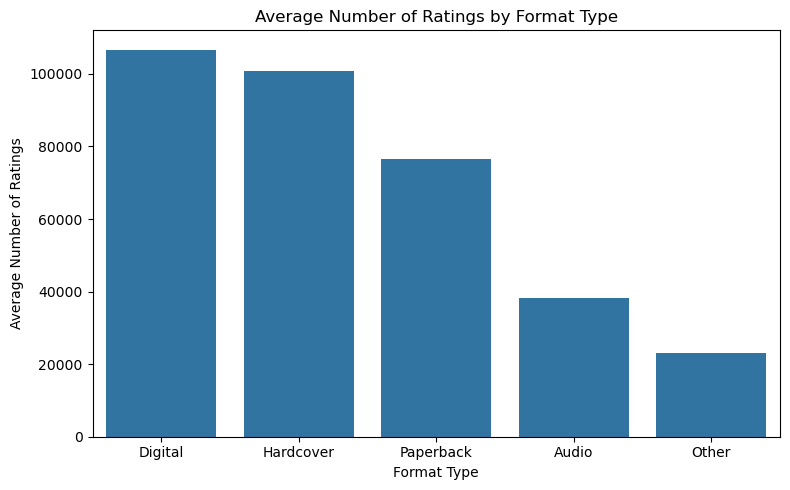

In [ ]:
plt.figure(figsize=(8,5))
format_engagement = file.groupby('format_type')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=format_engagement.index, y=format_engagement.values)
plt.title('Average Number of Ratings by Format Type')
plt.xlabel('Format Type')
plt.ylabel('Average Number of Ratings')
plt.tight_layout()
plt.show()

### Chart 2 - Boxplot: Distribution of Number of Ratings by Format Type

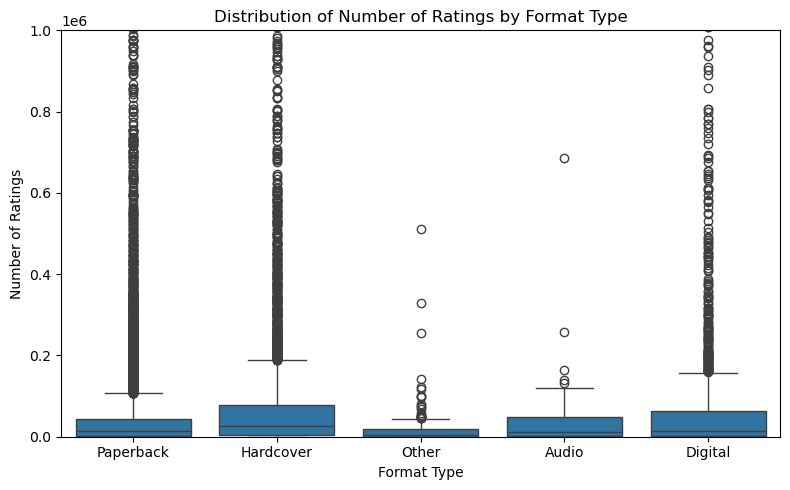

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='format_type', y='num_ratings', data=file)
plt.title('Distribution of Number of Ratings by Format Type')
plt.xlabel('Format Type')
plt.ylabel('Number of Ratings')
plt.ylim(0, 1000000)
plt.tight_layout()
plt.show()

While the bar chart suggested Digital books have the highest average engagement, the boxplot reveals that Hardcover books actually have 
the highest median number of ratings, suggesting that the typical Hardcover book receives more engagement than other formats. Digital's 
high average is driven by a small number of extreme outliers. Audio and Other formats consistently show the lowest engagement across 
the dataset.

### Chart 3 - Bar Chart: Average Number of Ratings by Book Length

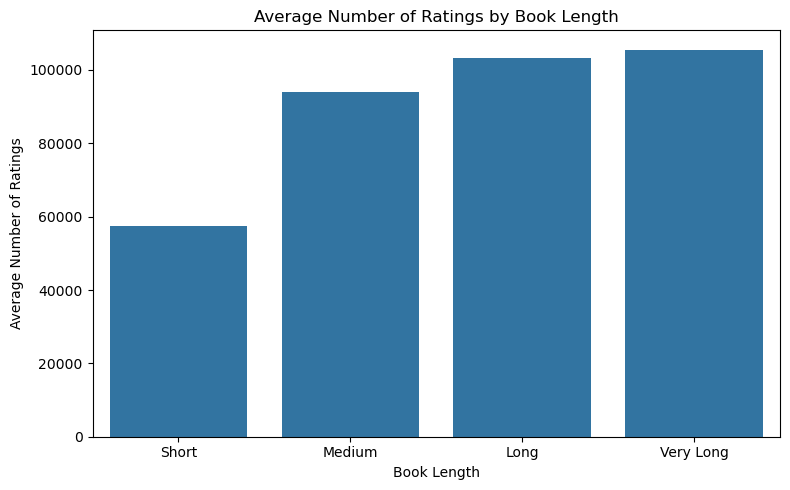

In [ ]:
plt.figure(figsize=(8,5))
length_engagement = file.groupby('length_bin')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=length_engagement.index, y=length_engagement.values)
plt.title('Average Number of Ratings by Book Length')
plt.xlabel('Book Length')
plt.ylabel('Average Number of Ratings')
plt.tight_layout()
plt.show()

There is a clear positive relationship between book length and reader engagement. Longer books consistently attract more ratings 
on average, with Very Long books receiving nearly double the average ratings of Short books. This suggests that readers who 
commit to longer books are more likely to engage by leaving a rating. However, this trend may also be influenced by the fact 
that longer books tend to be popular series installments or collected editions which naturally attract more readers.

### Chart 4 - Bar Chart: Average Number of Ratings by Genre (Top 10)

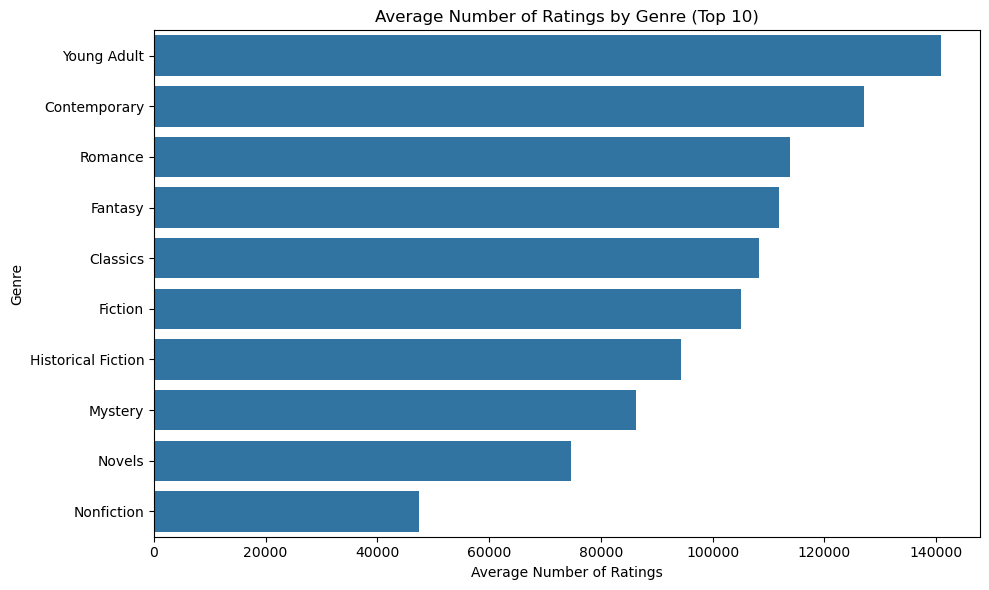

In [ ]:
from collections import Counter

# Get top 10 most common genres
all_genres = [genre for sublist in file['genres'] for genre in sublist]
top_genres = [genre for genre, count in Counter(all_genres).most_common(10)]

# Calculate average num_ratings for each top genre
genre_engagement = {}
for genre in top_genres:
    mask = file['genres'].apply(lambda x: genre in x)
    genre_engagement[genre] = file[mask]['num_ratings'].mean()

genre_df = pd.DataFrame(list(genre_engagement.items()), columns=['genre', 'avg_ratings'])
genre_df = genre_df.sort_values('avg_ratings', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='avg_ratings', y='genre', data=genre_df)
plt.title('Average Number of Ratings by Genre (Top 10)')
plt.xlabel('Average Number of Ratings')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

Young Adult books show the highest average reader engagement by a significant margin. This suggests genre 
is a strong predictor of reader engagement, with certain genres naturally attracting more active reader participation than others.  

Note: Books with multiple genres are counted in each of their respective genre groups, meaning a single book can contribute 
to multiple genre averages. This is intentional as the goal is to understand engagement patterns within each genre regardless of overlap.

### Chart 5 - Scatter Plot: Number of Ratings vs Average Rating

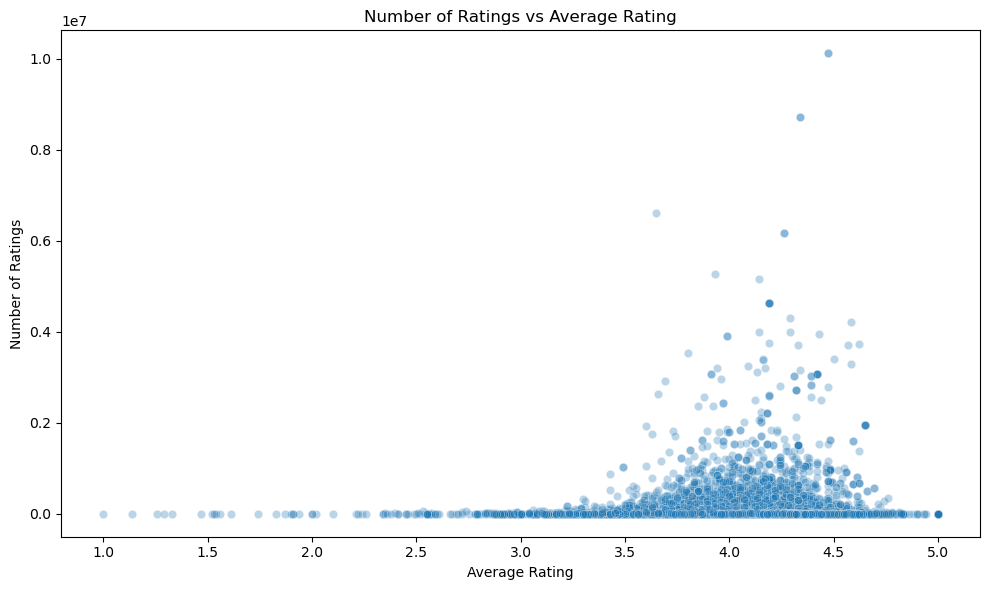

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='average_rating', y='num_ratings', data=file, alpha=0.3)
plt.title('Number of Ratings vs Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

The scatter plot reveals that highly engaged books tend to cluster around average ratings of 4.0-4.5 rather than perfect scores. 
Books with ratings close to 5.0 or below 3.0 generally have very low engagement, suggesting that extremely high ratings may reflect obscure books with few raters rather than genuinely popular titles. This suggests that the optimal range for quality and engagement is an average rating between 4.0 and 4.5.

### Chart 6 - Bar Chart: Average Number of Ratings by Publication Era

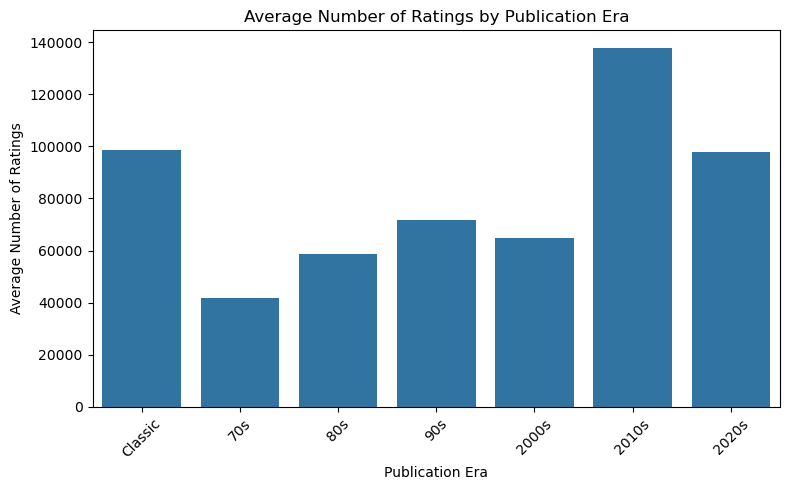

In [ ]:
plt.figure(figsize=(8,5))
era_engagement = file.groupby('era_bin')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=era_engagement.index, y=era_engagement.values)
plt.title('Average Number of Ratings by Publication Era')
plt.xlabel('Publication Era')
plt.ylabel('Average Number of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar graph shows the average number of ratings for books across different publication eras. Books published in the 2010s have the highest average number of ratings, indicating the greatest level of reader engagement. In contrast, books from the 1970s have the lowest average number of ratings. This trend may suggest that the rise of online book communities and digital platforms during the 2010s increased reader participation in rating and reviewing books. It could also indicate that more recently published books receive greater visibility and interaction from modern audiences compared to older publications.

### Chart 7 - Count Plot: Book Length vs Popularity Distribution

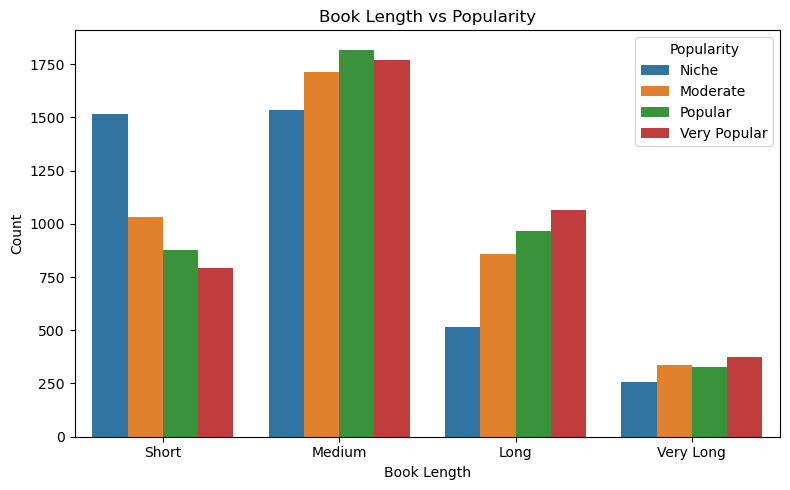

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='length_bin', hue='popularity_bin', data=file)
plt.title('Book Length vs Popularity')
plt.xlabel('Book Length')
plt.ylabel('Count')
plt.legend(title='Popularity')
plt.tight_layout()
plt.show()

The graph compares book length categories with different levels of popularity. Medium-length books appear most frequently across all popularity levels, especially among popular and very popular books. Short books are more common among niche titles but appear less often as popularity increases. Long and very long books become slightly more common as popularity increases, but they still occur less frequently than medium-length books overall. This pattern may suggest that medium-length books are the most appealing to a broad audience. It could also indicate that extremely short or very long books appeal to more specific audiences rather than the general reading population.

In [ ]:
print(file[['format_type', 'length_bin', 'rating_bin', 'popularity_bin', 'era_bin']].isnull().sum())

format_type         0
length_bin        270
rating_bin          0
popularity_bin      0
era_bin             1
dtype: int64


## Data Transformation
Each book is treated as a transaction where items represent its attributes including genre, format, length, rating, 
popularity, and publication era. FP-Growth was chosen over Apriori as it is more efficient for larger datasets, avoiding 
the candidate generation step.

In [ ]:
from collections import Counter

# Get top 15 most common genres
all_genres = [genre for sublist in file['genres'] for genre in sublist]
top_genres = set([genre for genre, count in Counter(all_genres).most_common(15)])

def make_transaction(row):
    items = []
    
    # Add genres (only top 15)
    for genre in row['genres']:
        if genre in top_genres:
            items.append(f"genre_{genre}")
    
    # Add binned attributes if not null
    if pd.notna(row['format_type']):
        items.append(f"format_{row['format_type']}")
    if pd.notna(row['length_bin']):
        items.append(f"length_{row['length_bin']}")
    if pd.notna(row['rating_bin']):
        items.append(f"rating_{row['rating_bin']}")
    if pd.notna(row['popularity_bin']):
        items.append(f"pop_{row['popularity_bin']}")
    if pd.notna(row['era_bin']):
        items.append(f"era_{row['era_bin']}")
    
    return items

file['transaction'] = file.apply(make_transaction, axis=1)
print(file['transaction'].head(5))

0    [genre_Fantasy, genre_Young Adult, genre_Ficti...
1    [genre_Young Adult, genre_Fiction, genre_Audio...
2    [genre_Fantasy, genre_Fiction, genre_Young Adu...
3    [genre_Fantasy, genre_Fiction, genre_Young Adu...
4    [genre_Fantasy, genre_Young Adult, genre_Ficti...
Name: transaction, dtype: object


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit_transform(file['transaction'])
te_df = pd.DataFrame(te_array, columns=te.columns_)
te_df.index = ['T' + str(i+1) for i in range(len(te_df))] 


print(te_df.shape)
print(te_df.head())

(16021, 39)
    era_2000s  era_2010s  era_2020s  era_70s  era_80s  era_90s  era_Classic  \
T1       True      False      False    False    False    False        False   
T2       True      False      False    False    False    False        False   
T3      False      False      False    False    False     True        False   
T4      False      False      False    False    False     True        False   
T5      False      False      False    False    False     True        False   

    format_Audio  format_Digital  format_Hardcover  ...  length_Short  \
T1         False           False             False  ...         False   
T2         False           False             False  ...         False   
T3         False           False              True  ...         False   
T4         False           False             False  ...         False   
T5         False           False             False  ...         False   

    length_Very Long  pop_Moderate  pop_Niche  pop_Popular  pop_Very Popul

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Find frequent itemsets
frequent_itemsets = fpgrowth(te_df, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Number of frequent itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.head(20))

Number of frequent itemsets: 411
      support                                      itemsets
0    0.707509                    frozenset({genre_Fiction})
1    0.597216                 frozenset({format_Paperback})
36   0.439611  frozenset({format_Paperback, genre_Fiction})
9    0.426565                    frozenset({length_Medium})
2    0.323014                        frozenset({era_2000s})
3    0.316959                    frozenset({genre_Fantasy})
119  0.295550     frozenset({length_Medium, genre_Fiction})
10   0.291305                 frozenset({format_Hardcover})
20   0.277074                      frozenset({rating_High})
15   0.263467                     frozenset({length_Short})
44   0.263217     frozenset({genre_Fiction, genre_Fantasy})
4    0.256726                 frozenset({rating_Very High})
25   0.250109                        frozenset({pop_Niche})
21   0.250047                    frozenset({rating_Medium})
5    0.249984                 frozenset({pop_Very Popular})
13   0.

In [ ]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules = rules.sort_values('lift', ascending=False)

print(f"Number of rules: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

Number of rules: 806
                                           antecedents  \
206              frozenset({genre_Historical Fiction})   
202       frozenset({genre_Historical, genre_Fiction})   
575              frozenset({genre_Historical Fiction})   
565  frozenset({genre_Historical, format_Paperback,...   
572  frozenset({format_Paperback, genre_Historical ...   
570       frozenset({genre_Historical, genre_Fiction})   
618            frozenset({era_Classic, genre_Fiction})   
613      frozenset({genre_Classics, genre_Literature})   
573  frozenset({genre_Fiction, genre_Historical Fic...   
569    frozenset({genre_Historical, format_Paperback})   
521    frozenset({genre_Historical, format_Paperback})   
525              frozenset({genre_Historical Fiction})   
760         frozenset({era_Classic, genre_Literature})   
757      frozenset({genre_Classics, format_Paperback})   
191              frozenset({genre_Historical Fiction})   
190                      frozenset({genre_Historica

min_support=0.05 was chosen to capture patterns appearing in at least 5% of books while filtering out rare combinations. 
min_threshold=0.3 was chosen to balance rule quantity 
with reliability given the dataset size.

In [ ]:
# Filter for rules where the outcome is about engagement
engagement_rules = rules[rules['consequents'].astype(str).str.contains('pop_')]
engagement_rules = engagement_rules.sort_values('lift', ascending=False)

print(f"Number of engagement rules: {len(engagement_rules)}")
print(engagement_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

Number of engagement rules: 39
                                        antecedents  \
561     frozenset({genre_Audiobook, genre_Fiction})   
562                    frozenset({genre_Audiobook})   
342                    frozenset({genre_Audiobook})   
455           frozenset({era_2010s, genre_Fiction})   
677           frozenset({genre_Historical Fiction})   
264                          frozenset({era_2010s})   
788                 frozenset({genre_Contemporary})   
389                  frozenset({genre_Young Adult})   
457                          frozenset({era_2010s})   
463       frozenset({genre_Romance, genre_Fiction})   
787  frozenset({genre_Contemporary, genre_Fiction})   
387   frozenset({genre_Young Adult, genre_Fiction})   
328    frozenset({format_Hardcover, genre_Fiction})   
301                         frozenset({rating_Low})   
180                       frozenset({length_Short})   
544                   frozenset({genre_Nonfiction})   
597                 frozenset({gen

In [ ]:
very_popular_rules = engagement_rules[
    engagement_rules['consequents'].astype(str) == "frozenset({'pop_Very Popular'})"
]
very_popular_rules = very_popular_rules.sort_values('lift', ascending=False)
print(very_popular_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                                        antecedents  \
561     frozenset({genre_Audiobook, genre_Fiction})   
342                    frozenset({genre_Audiobook})   
455           frozenset({era_2010s, genre_Fiction})   
264                          frozenset({era_2010s})   
463       frozenset({genre_Romance, genre_Fiction})   
787  frozenset({genre_Contemporary, genre_Fiction})   
387   frozenset({genre_Young Adult, genre_Fiction})   
328    frozenset({format_Hardcover, genre_Fiction})   
597                 frozenset({genre_Contemporary})   
382         frozenset({rating_High, genre_Fiction})   
325                  frozenset({genre_Young Adult})   
601         frozenset({genre_Fiction, length_Long})   
224       frozenset({genre_Fiction, genre_Fantasy})   
294                      frozenset({genre_Romance})   
802    frozenset({genre_Fiction, rating_Very High})   
182                   frozenset({format_Hardcover})   
159                      frozenset({genre_Fantasy})   
417       

In [ ]:
for _, row in very_popular_rules.head(20).iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"{{{antecedents}}} → {{{consequents}}}")
    print(f"support = {row['support']:.3f}, confidence = {row['confidence']:.3f}, lift = {row['lift']:.3f}")
    print() 

{genre_Audiobook, genre_Fiction} → {pop_Very Popular}
support = 0.059, confidence = 0.598, lift = 2.393

{genre_Audiobook} → {pop_Very Popular}
support = 0.072, confidence = 0.572, lift = 2.290

{era_2010s, genre_Fiction} → {pop_Very Popular}
support = 0.063, confidence = 0.493, lift = 1.972

{era_2010s} → {pop_Very Popular}
support = 0.083, confidence = 0.408, lift = 1.634

{genre_Romance, genre_Fiction} → {pop_Very Popular}
support = 0.062, confidence = 0.375, lift = 1.499

{genre_Contemporary, genre_Fiction} → {pop_Very Popular}
support = 0.051, confidence = 0.370, lift = 1.478

{genre_Young Adult, genre_Fiction} → {pop_Very Popular}
support = 0.068, confidence = 0.367, lift = 1.469

{format_Hardcover, genre_Fiction} → {pop_Very Popular}
support = 0.075, confidence = 0.366, lift = 1.463

{genre_Contemporary} → {pop_Very Popular}
support = 0.057, confidence = 0.356, lift = 1.425

{rating_High, genre_Fiction} → {pop_Very Popular}
support = 0.068, confidence = 0.350, lift = 1.401

{gen

Audiobook appears as both a genre tag and format type in the Goodreads dataset, reflecting inconsistent categorization by users. The strong association between Audiobook and high engagement holds regardless of whether it is treated as a genre or format attribute.

## Preliminary Findings

FP-Growth identified 19 rules associating book attributes with high reader engagement. The strongest rule found was Audiobook + Fiction (support=0.059, confidence=0.598, lift=2.39), meaning Audiobook Fiction books are 2.4x more likely to be Very Popular than a random book.

Publication era was significant — Fiction books from the 2010s showed nearly 2x higher engagement (lift=1.97). Genre combinations also mattered — Romance Fiction (lift=1.50), Contemporary Fiction (lift=1.48), and Young Adult Fiction (lift=1.47) all associated with higher engagement.

Surprisingly, book length and average rating were weak predictors of engagement, suggesting genre and format matter more than quality or length alone.

Limitations: 
- The dataset is heavily skewed toward Paperback and Hardcover formats which may limit format-related rules. 
- Audiobook appears as both a genre and format tag reflecting inconsistent data categorization.

Next Steps: In M3 anomaly detection will be applied to Q2 to identify books with unusually high or low ratings within 
their genre, and clustering will be applied to Q3 to identify author productivity patterns.


### Q2: Anomaly Detection

**Discovery Questions**: Which books receive unusually high or liw ratings compared to similar books in their genre?

Anomaly detection techniques will be used to identify books whose ratings significantly differ from typical rating patterns within their specific genres. By comparing individual books based on attributes such as average rating and number of reviews, this analysis will highlight books that are unusually highly rated or poorly rated relative to their genre. This technique will uncover outliers that may represent reader reception and potential data inconsistencies.


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Log-scale num_ratings to reduce skew
file['log_ratings'] = np.log1p(file['num_ratings'])

top_genres = [g for g, _ in Counter(
    [g for sublist in file['genres'] for g in sublist]
).most_common(10)]

Local Outlier Factor (LOF) was chosen because it detects anomalies relative to local neighborhoods rather than global thresholds. This makes it ideal for genre-based comparison. A 4.8 rating in a genre that typically clusters around 3.9 is flagged, even if 4.8 is not globally unusa. LOF is run separately per genre so each book is compared only to its genre. 

In [ ]:
file['lof_score'] = np.nan
file['is_anomaly'] = False

for genre in top_genres:
    mask = file['genres'].apply(lambda x: genre in x)
    subset = file[mask].copy()
    
    if len(subset) < 20:  # need enough neighbors
        continue
    
    features = subset[['average_rating', 'log_ratings']].dropna()
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    preds = lof.fit_predict(X)
    scores = lof.negative_outlier_factor_
    
    file.loc[features.index, 'lof_score'] = scores
    file.loc[features.index[preds == -1], 'is_anomaly'] = True

print(f"Total anomalies flagged: {file['is_anomaly'].sum()}")

Total anomalies flagged: 1297


### Anomaly Investigation

Anomalies are split into two categories: 

- **High-rated anomalies**: Books rated above 4.3 that stand out within their genre - likely niche titles with small but devoted audiences
- **Low-rated anaomlies**: Books rated below 3.8 that underperform relative to genre peers - may reflect assigned-reading bias or unreliable ratings from low sample sizes

These thresholds were chosen based on the ratings bins established in M2 preprocessing, where book ratings above 4.2 was classified as "Very High" and all books ratings below 3.8 are "Low" 

In [ ]:
anomalies = file[file['is_anomaly'] == True][
    ['book_title', 'average_rating', 'num_ratings', 'genres', 'format_type', 'era_bin']
].sort_values('average_rating', ascending=False)

print("High-rated anomalies (obscure but loved):")
print(anomalies[anomalies['average_rating'] > 4.3].head(10))

print("\nLow-rated anomalies (unusually disliked):")
print(anomalies[anomalies['average_rating'] < 3.8].head(10))

High-rated anomalies (obscure but loved):
                                              book_title  average_rating  \
15207     100 Fun Bible Facts: The Exciting way to Learn            4.93   
15335  100 Bible Facts About Jesus: The Exciting way ...            4.90   
4836                           The Knights of King Midas            4.83   
13135                                  Hunt for the Star            4.83   
11775  The German Revolution and the Debate on Soviet...            4.83   
12568                                           Blackout            4.82   
15736                            The Addiction Manifesto            4.82   
15834  Heaven Official's Blessing: Tian Guan Ci Fu (N...            4.82   
12975                                  Сад Гетсиманський            4.82   
1867                      The Complete Calvin and Hobbes            4.81   

       num_ratings                                             genres  \
15207          232                            [N

### Determining Anomaly Thresholds 

An initial threshold of 4.3 (high) and 3.8 (low) was tested but produced inconsistent results. A quantitle-based approach was adopted instead, using the 75th and 25th percentiles of the anomaly distribution to ensure thresholds adapt to the actual data rahter than arbitrary cutoffs. 

In [ ]:
high_threshold = anomalies['average_rating'].quantile(0.75)
print(f"High-rated threshold: {high_threshold:.2f}")

print("\nHigh-rated anomalies (obscure but loved):")
print(anomalies[anomalies['average_rating'] >= high_threshold].head(10))

High-rated threshold: 4.45

High-rated anomalies (obscure but loved):
                                              book_title  average_rating  \
15207     100 Fun Bible Facts: The Exciting way to Learn            4.93   
15335  100 Bible Facts About Jesus: The Exciting way ...            4.90   
4836                           The Knights of King Midas            4.83   
13135                                  Hunt for the Star            4.83   
11775  The German Revolution and the Debate on Soviet...            4.83   
12568                                           Blackout            4.82   
15736                            The Addiction Manifesto            4.82   
15834  Heaven Official's Blessing: Tian Guan Ci Fu (N...            4.82   
12975                                  Сад Гетсиманський            4.82   
1867                      The Complete Calvin and Hobbes            4.81   

       num_ratings                                             genres  \
15207          232  

In [ ]:
threshold = anomalies['average_rating'].quantile(0.25)
print(f"Low-rated threshold: {threshold:.2f}")

print("\nLow-rated anomalies:")
print(anomalies[anomalies['average_rating'] <= threshold].head(10))

Low-rated threshold: 3.51

Low-rated anomalies:
                                 book_title  average_rating  num_ratings  \
11573  The Short Second Life of Bree Tanner            3.51       223116   
4241                            Coastliners            3.51         9016   
12381        Me and Earl and the Dying Girl            3.51       142395   
12455                   Poseidon’s Children            3.51          435   
10983                  Guardian of the Dead            3.51         3286   
9826                            سقف الكفاية            3.50         9025   
2222                Lady Chatterley’s Lover            3.50       126216   
9152                      Leaves of Fortune            3.50          109   
15278               Lady Chatterley's Lover            3.50       126243   
16129                      Prince of Pain I            3.50          131   

                                                  genres format_type  era_bin  
11573  [Fantasy, Young Adult, Vampi

### Chart 8: Scatter Plot - LOF Anomaly Detection - Rating vs Engagement 

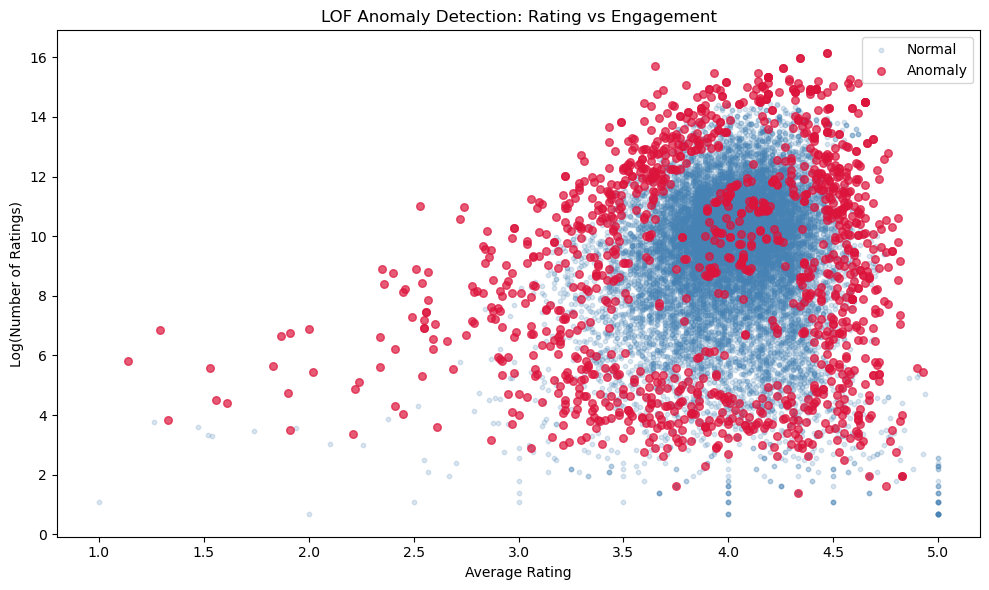

In [ ]:
plt.figure(figsize=(10, 6))
normal = file[file['is_anomaly'] == False]
anomaly = file[file['is_anomaly'] == True]

plt.scatter(normal['average_rating'], normal['log_ratings'],
            alpha=0.2, label='Normal', color='steelblue', s=10)
plt.scatter(anomaly['average_rating'], anomaly['log_ratings'],
            alpha=0.7, label='Anomaly', color='crimson', s=30)

plt.xlabel('Average Rating')
plt.ylabel('Log(Number of Ratings)')
plt.title('LOF Anomaly Detection: Rating vs Engagement')
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot maps all books by their average rating and log-scaled number of ratings. Books flagged as anomlalies by LOF are highlighted in red. Normal books, books with no anomalies, are shown in blue. 

Log-scaling is applied to num_ratings to reduce the effect of extreme outliers and make the distribution more readable. 

This visualization shows where anomalies cluster in the rating-engagment spacs. Anomalies appearing in the far right (high rating, low engagment) represent obscure but beloved niche titles, while anomalies in the lower left (low rating, lower engagmenet) represent books that underperform relative to their genre peers.  

### Chart 9: Bar Chart - Number of Ratings Anomalies by Genre 

/var/folders/md/bql98n851j5563bm5bl3d9680000gn/T/ipykernel_7000/3583346396.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Anomaly Count', y='Genre', data=genre_anomaly_df, palette='Reds_r')


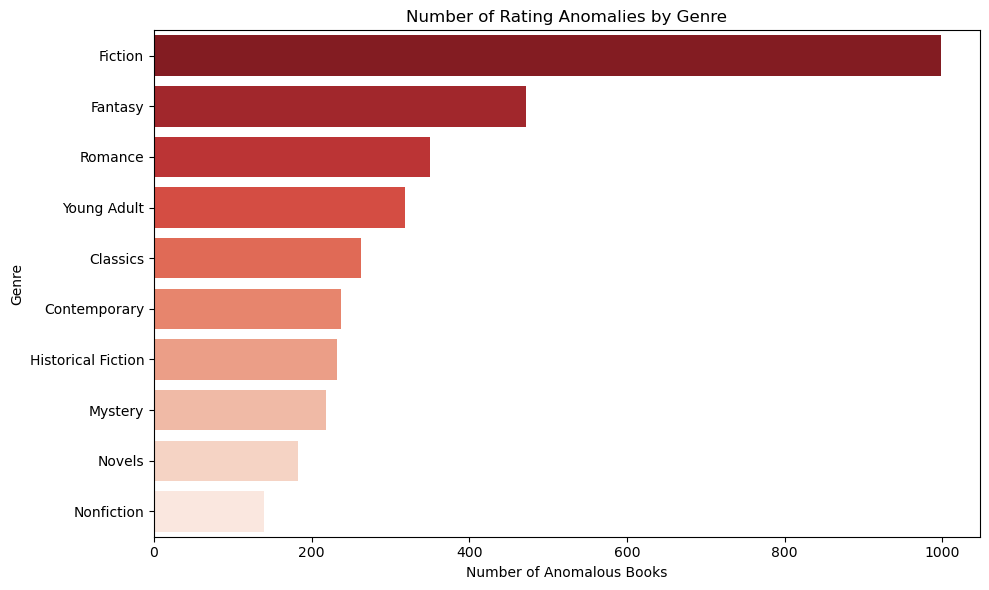

In [ ]:

genre_anomaly_counts = {}

for genre in top_genres:
    mask = file['genres'].apply(lambda x: genre in x)
    total = mask.sum()
    anomaly_count = file[mask & (file['is_anomaly'] == True)].shape[0]
    genre_anomaly_counts[genre] = anomaly_count

genre_anomaly_df = pd.DataFrame(list(genre_anomaly_counts.items()), 
                                 columns=['Genre', 'Anomaly Count'])
genre_anomaly_df = genre_anomaly_df.sort_values('Anomaly Count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Anomaly Count', y='Genre', data=genre_anomaly_df, palette='Reds_r')
plt.title('Number of Rating Anomalies by Genre')
plt.xlabel('Number of Anomalous Books')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The bar chart shows the total number of LOF-flagged anomalies across the top 10 genres, This highlights which genres produce the most books with unusual rating patterns relative to their genre peers. 

Fiction and Fantasy contain the highest number of rating anomalies, which is expected given they are the largest genres in the dataset. However, the presence of anomalies across all genres comfirms that unusual rating patterns are not isolated to one category - they reflect a broader pattern of niche and culturally assigned reads throughout the dataset. 

### Chart 10: Bar Chart - High vs Low Rating Anomalies by Genre 

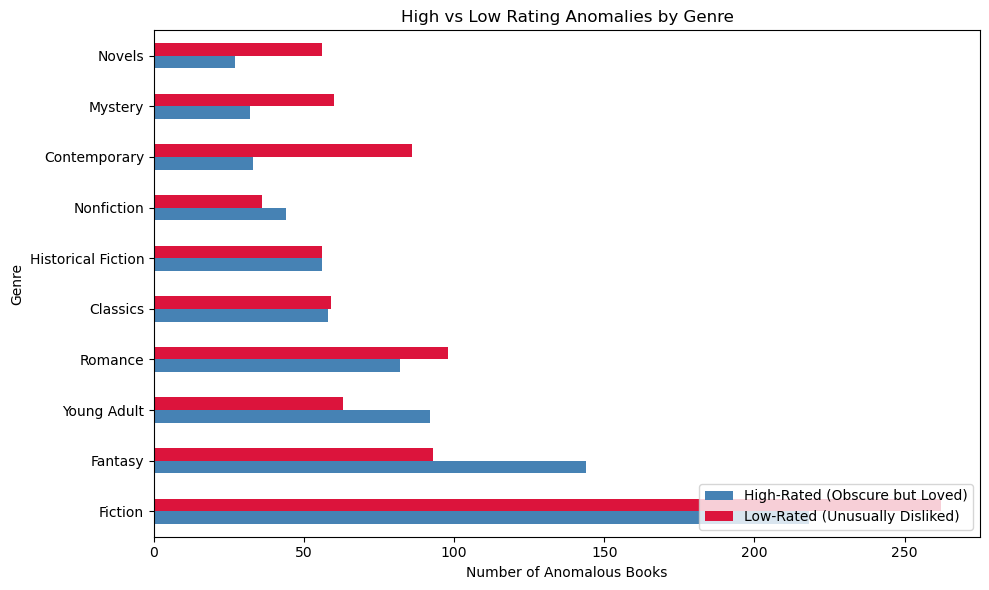

In [ ]:
high_anomalies = file[(file['is_anomaly'] == True) & (file['average_rating'] >= high_threshold)]
low_anomalies = file[(file['is_anomaly'] == True) & (file['average_rating'] <= threshold)]

high_counts = {}
low_counts = {}

for genre in top_genres:
    high_counts[genre] = high_anomalies['genres'].apply(lambda x: genre in x).sum()
    low_counts[genre] = low_anomalies['genres'].apply(lambda x: genre in x).sum()

anomaly_split_df = pd.DataFrame({
    'Genre': top_genres,
    'High-Rated (Obscure but Loved)': [high_counts[g] for g in top_genres],
    'Low-Rated (Unusually Disliked)': [low_counts[g] for g in top_genres]
}).set_index('Genre').sort_values('High-Rated (Obscure but Loved)', ascending=False)

anomaly_split_df.plot(kind='barh', figsize=(10, 6), color=['steelblue', 'crimson'])
plt.title('High vs Low Rating Anomalies by Genre')
plt.xlabel('Number of Anomalous Books')
plt.ylabel('Genre')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

This chart splits LOF-flagged anomalies into two categories by genre, books that are unusually highly rated and books that are unusually poorly rated. Thresholds are based on the 75th and 25th percentiles of the anomaly distribution established earlier. This directly addresses Q2 by showing which genres produce the most extreme rating outliers in each direction. 

### Chart 11: Histogram - Rating Distribution: Anomalies vs Non-Anomaly Books 

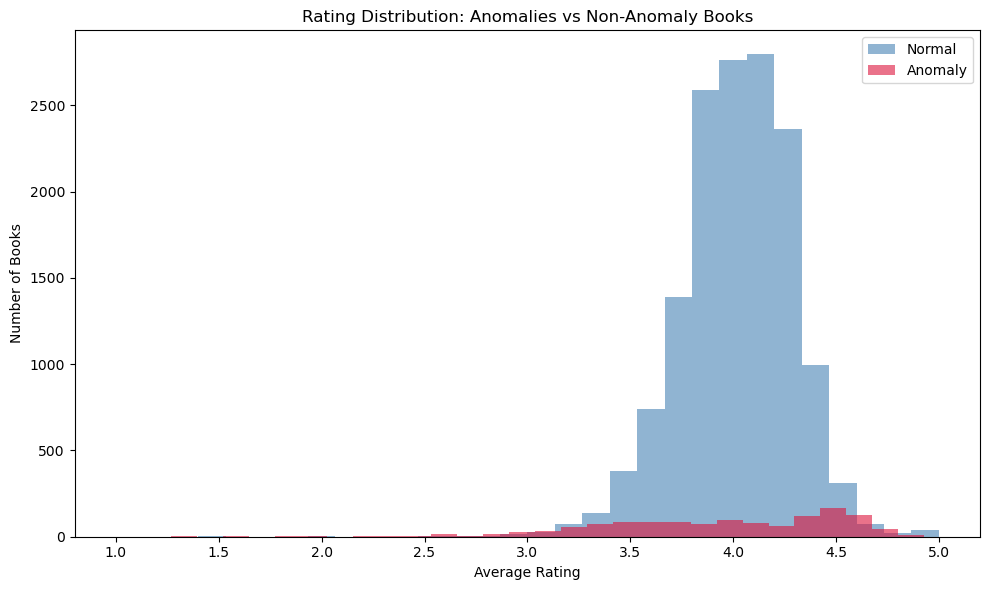

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(file[file['is_anomaly'] == False]['average_rating'], 
         bins=30, alpha=0.6, label='Normal', color='steelblue')
plt.hist(file[file['is_anomaly'] == True]['average_rating'], 
         bins=30, alpha=0.6, label='Anomaly', color='crimson')
plt.title('Rating Distribution: Anomalies vs Non-Anomaly Books')
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.legend()
plt.tight_layout()
plt.show()

Non-anomaly books cluster tightly between 3.5 and 4.5, peaking around 3.9-4.1, reflecting the typical Goodreads rating distribution. Anomalus books follow a similar range but are spread much more evenly across the full rating scale, including ratings below 3.0 and above 4.5 where non-anomalus book are nearly absent. 

This comfirms that LOF is successfully identifying books that sit outside the dense rating cluster of their genre peers. The tail of anonmalies extending below 2.5 represent genuinely poorly reveived books, while the anomalies aobe 45 represent the niche beloved titles. 

## Preliminary Findings 

LOF identified anomalous books across all top 10 genres by comparing each book's rating and engagement level agasint its genre neighbors. Two distinct anomaly patterns emerged: 

**High-rated anomalies** (above the 75th percentiles threshold) are most concentrated in Fiction (~270), Fantasy (~145), and Young Adult (~90). These are nichee titles with small but intesely loyal audiences. 

**Low-rated anomalies** (below the 25th percentile thresholds) are highest in Fiction (~185), Romance (~95), and Contemporary (~85). Romance and Contemporary show a notably higher proportion of low-rated anomalies relative to their high-rated ones, suggesting these genres produce more books that underperform reader expectations. Classics shows a balanced split consistent with the assigned-reading pattern.

Fiction has by far the most total anomalies (~1000), followed by Fantasy (~470) and Romance (~350), consistent with these being the largest genres in the dataset. Nonfiction has the fewest anomalies (~140), suggesting its ratings tend to be more consistent relative 
to genre peers.

Anomalies are not random noise, they follow predictable patterns tied to genre context, audience size, and cultural reading habits. This confirms that unusual ratings are meaningful signals rather than data errors.

**Limitations**:
- LOF results are sensitive to the n_neighbors parameter (set to 20) — 
  a smaller value may flag more anomalies in dense genres
- Books appearing in multiple genres may be flagged multiple times, 
  inflating anomaly counts in overlapping genres like Fiction and Fantasy

## Q3: Clustering - Author Productivity and Quality Patterns

**Discovery Question**: What patterns in productivity and book quality distinguish successful authors from struggling authors?

Clustering techniques will be used to group authors based on shared patterns in productivity and book quality, using attributes such as number of books published, average book ratings, and total number of reviews. Algorithms such as Kmeans and hierarchical clustering may be applied to identify groups of authors with similar characteristics. These clusters will identify combinations of productivity and quality metrics that differentiate successful authors from struggling authors.

In [ ]:
author_counts = file.groupby('author')['book_title'].count()
print(author_counts.describe())
print(f"\nAuthors with 2+ books: {(author_counts >= 2).sum()}")
print(f"Authors with 5+ books: {(author_counts >= 5).sum()}")

count    7501.000000
mean        2.135849
std         3.159506
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        79.000000
Name: book_title, dtype: float64

Authors with 2+ books: 2454
Authors with 5+ books: 681


The intitial output shows most authors only appear once in the dataset, with a median of 1 book. Authors with only 1-2 books do not provide enough signal to meanigfully distingusish productivity patterns. A second check was run to find a suitable minimum book threshold that balances sample size with analytical meanigfullness. 

In [ ]:
author_counts = file.groupby('author')['book_title'].count()
print(f"Authors with 3+ books: {(author_counts >= 3).sum()}")
print(f"Authors with 4+ books: {(author_counts >= 4).sum()}")

Authors with 3+ books: 1408
Authors with 4+ books: 923


Authors with 3+ books provide a sufficient sample while ensuring each author has enough books to establish a meanigful productivity and quality patter. This thresfold was selected for clustering. 

In [ ]:
author_counts = file.groupby('author')['book_title'].count()
qualified_authors = author_counts[author_counts >= 3].index

author_df = file[file['author'].isin(qualified_authors)].groupby('author').agg(
    num_books=('book_title', 'count'),
    avg_rating=('average_rating', 'mean'),
    total_ratings=('num_ratings', 'sum'),
    avg_ratings_per_book=('num_ratings', 'mean')
).reset_index()

print(author_df.shape)
print(author_df.describe())

(1408, 5)
         num_books   avg_rating  total_ratings  avg_ratings_per_book
count  1408.000000  1408.000000   1.408000e+03          1.408000e+03
mean      6.308239     4.022941   7.816000e+05          9.967633e+04
std       5.581102     0.236573   2.634085e+06          2.282110e+05
min       3.000000     1.702857   1.400000e+01          4.666667e+00
25%       3.000000     3.884750   4.492650e+04          1.165433e+04
50%       4.000000     4.026667   1.664965e+05          3.343788e+04
75%       7.000000     4.170357   5.701358e+05          8.983131e+04
max      79.000000     5.000000   4.647317e+07          4.197336e+06


Total ratings and average ratings per book are heavily skewed. Log-scaling reduces the influence of extreme outliers and ensures these features don't dominate. 

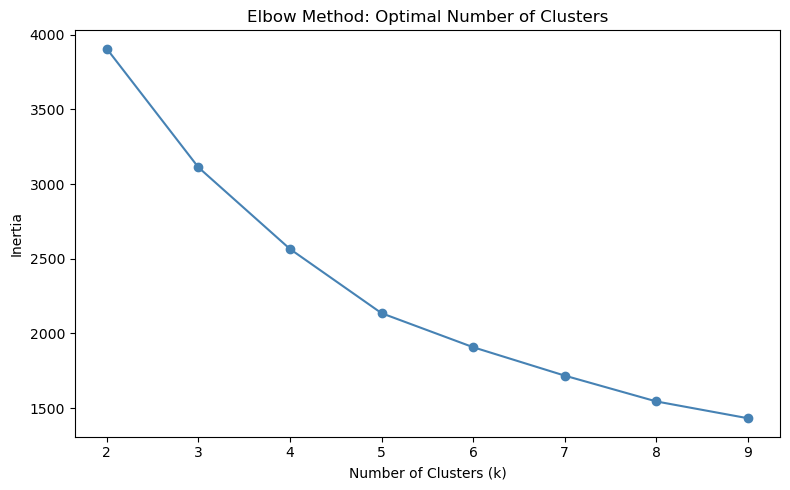

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

author_df['log_total_ratings'] = np.log1p(author_df['total_ratings'])
author_df['log_avg_ratings_per_book'] = np.log1p(author_df['avg_ratings_per_book'])

features = ['num_books', 'avg_rating', 'log_total_ratings', 'log_avg_ratings_per_book']
X = author_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

All four features are on different scales. StandardScaler transforms all features to have mean 0 and standard deviation 1 so each feature contributes equally to the clustering. 

The elbow curve does not show a sharp bend, which is common with author rpoductivity data due to its natural spread. The rate of decrease slows most noticeable after k=4, where additional clusters produce diminishing retuns in inertia reduction. K=4 was selected as it provides meaningful author segments whole avoiding over-segmentation. 

In [ ]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
author_df['cluster'] = km.fit_predict(X_scaled)

# Cluster summary
cluster_summary = author_df.groupby('cluster').agg(
    num_authors=('author', 'count'),
    avg_books=('num_books', 'mean'),
    avg_rating=('avg_rating', 'mean'),
    avg_total_ratings=('total_ratings', 'mean'),
    avg_ratings_per_book=('avg_ratings_per_book', 'mean')
).round(2)

print(cluster_summary)

         num_authors  avg_books  avg_rating  avg_total_ratings  \
cluster                                                          
0                640       5.98        4.10          880066.76   
1                243       4.00        4.17           15838.72   
2                426       4.50        3.82          132321.60   
3                 99      21.89        4.06         4818508.25   

         avg_ratings_per_book  
cluster                        
0                   161161.39  
1                     4123.71  
2                    31548.68  
3                   229890.73  


### Cluster Interpretation

Four distinct author profiles emerged:

- **Cluster 3 — Bestselling Powerhouses** (99 authors): Highly prolific with an average of 22 books and 4.8M total ratings. These are the most commercially successful authors in the dataset.
- **Cluster 0 — Established Authors** (640 authors): The largest group with solid productivity (6 books) and strong reach (880k ratings).
- **Cluster 2 — Developing Authors** (426 authors): Moderate output but the lowest average rating (3.82), suggesting quality challenges.
- **Cluster 1 — Niche Quality Authors** (243 authors): Low output and reach but the highest average rating (4.17) — small but loyal audiences.

### Chart 12: Scatter Plot - Author Clusters: Producivity vs Average Rating

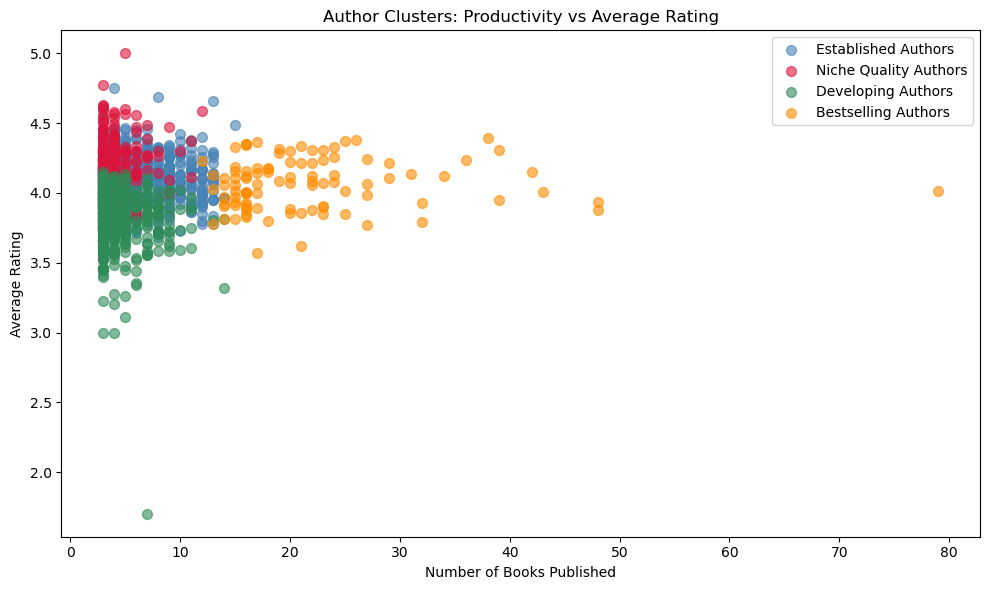

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'crimson', 'seagreen', 'darkorange']
labels = ['Established Authors', 'Niche Quality Authors', 
          'Developing Authors', 'Bestselling Authors']

for cluster_id in range(4):
    mask = author_df['cluster'] == cluster_id
    plt.scatter(
        author_df[mask]['num_books'],
        author_df[mask]['avg_rating'],
        c=colors[cluster_id],
        label=labels[cluster_id],
        alpha=0.6,
        s=50
    )

plt.title('Author Clusters: Productivity vs Average Rating')
plt.xlabel('Number of Books Published')
plt.ylabel('Average Rating')
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot shows clear seperation between the four author clusters. 

Bestselling authors (orange) are spread across the fll productivity range with conssitently solid ratings, confirming that high output does not come at the cost of quality for the most successful authors. 
Niche Qaulity Authors (red) cluster tightly in the low productivty range (under 10 books) but achieve some of the highest average ratings in the dataset, confirming their small but devoted audiecne pattern.
Developing Authors (green) also cluster at low productivity but show the widest rating spread, including the lowest reated author in the dataset. This suggest this group contains authors still finding their audienece. Established Authors (blue) form the densest cluster at low-to-moderate producitvity with consistently good ratings, representing the largest and most stable author segment. 

### Chart 13: Bar Chart - Cluster Profile Comparison 

/var/folders/md/bql98n851j5563bm5bl3d9680000gn/T/ipykernel_7000/178135316.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
/var/folders/md/bql98n851j5563bm5bl3d9680000gn/T/ipykernel_7000/178135316.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
/var/folders/md/bql98n851j5563bm5bl3d9680000gn/T/ipykernel_7000/178135316.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)


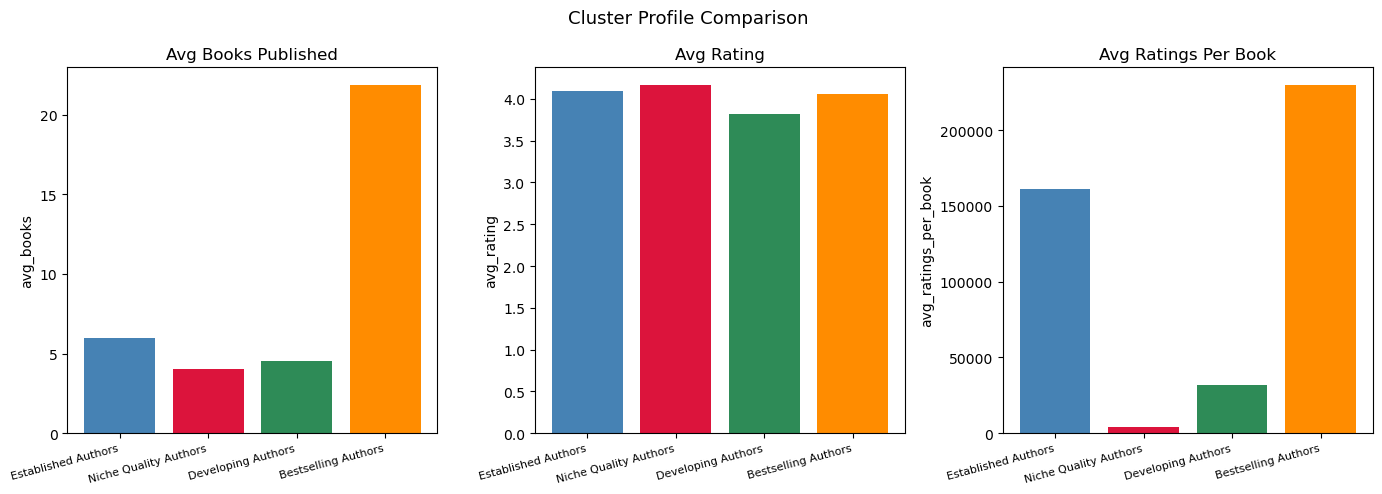

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['avg_books', 'avg_rating', 'avg_ratings_per_book']
titles = ['Avg Books Published', 'Avg Rating', 'Avg Ratings Per Book']
colors = ['steelblue', 'crimson', 'seagreen', 'darkorange']

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(labels, cluster_summary[metric], color=colors)
    ax.set_title(title)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel(metric)

plt.suptitle('Cluster Profile Comparison', fontsize=13)
plt.tight_layout()
plt.show()

The bar chart comfirms the distinct profiles of each author cluster across three key metrics:

- **Avg Books Published**: Bestselling Authors publish significally more books (about 20) than all other custers, while Niche Quality Authors and Developoing Authors average only 4 books each. 
- **Avg Rating**: Rating difference between clusters are surprisingly small, all clusters dall between 3.5 to above 4.0. This suggests that rating alone does not distiniguish successful authors from struggling ones. 
- **Avg Ratings Per Boos**: Bestselling aurhors receive over 200k ratings per book and Establish Authors about 160k, while Niche Quality Authors recieve only ~ 5k per book despite having the highest average rating. This suggest that commerical success is driven more by audience reach than by rating quality alone. 

### Chart 14: Top 5 Authors by Total Ratings Per Cluster 

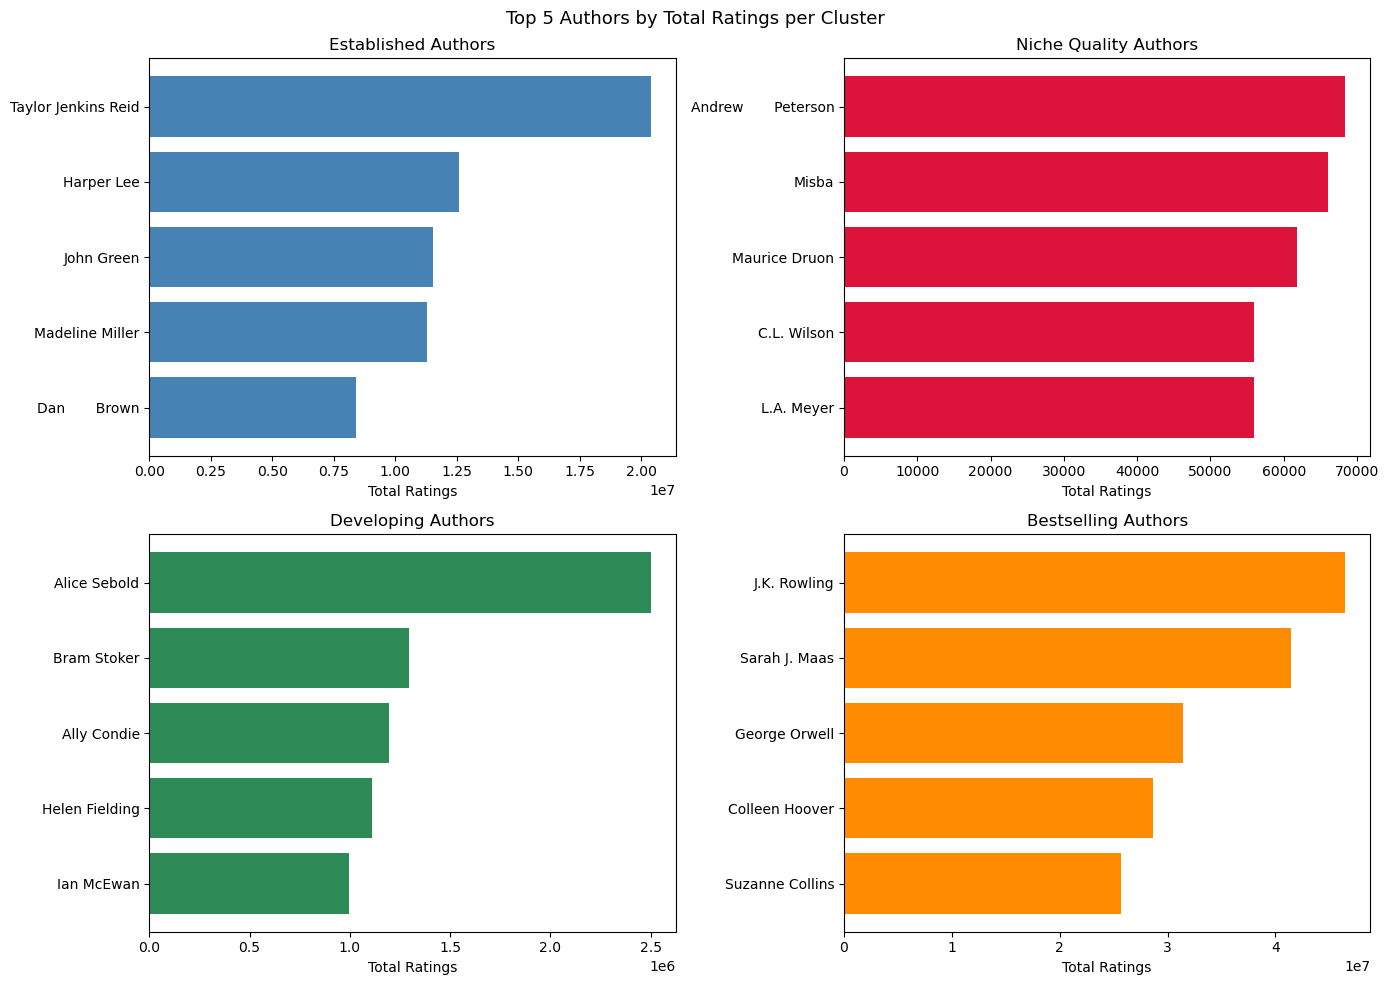

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
labels = ['Established Authors', 'Niche Quality Authors', 
          'Developing Authors', 'Bestselling Authors']
colors = ['steelblue', 'crimson', 'seagreen', 'darkorange']

for cluster_id in range(4):
    top_authors = author_df[author_df['cluster'] == cluster_id].nlargest(5, 'total_ratings')
    axes[cluster_id].barh(top_authors['author'], top_authors['total_ratings'], 
                          color=colors[cluster_id])
    axes[cluster_id].set_title(f'{labels[cluster_id]}')
    axes[cluster_id].set_xlabel('Total Ratings')
    axes[cluster_id].invert_yaxis()

plt.suptitle('Top 5 Authors by Total Ratings per Cluster', fontsize=13)
plt.tight_layout()
plt.show()

This chart shows the top 5 most-read authors within each cluster, providing real-world contract for the cluster profiles identified by K-Means. 

## Preliminary Findings

K-means clustering (k=4) indetified four distinct author profiles based on producitivy, average rating, and audience reach. The optimal k was selected using the elbow method, where inertia reduction became marginal after k=4. 

**Four author clusters emerged:**

- **Bestselling Powerhouses** (99 authors): The most commercially 
  successful group — averaging over 20 books published and 230k ratings per book. Represented by J.K. Rowling, Sarah J. Maas, and Suzanne Collins.

- **Established Authors** (640 authors): The largest cluster, solid productivity (avg 6 books) and strong reach (160k ratings per book). Represented by Taylor Jenkins Reid, John Green, and Madeline Miller.

- **Developing Authors** (426 authors): Moderate output but the lowest average rating (3.82) and modest reach (31k ratings per book). Represented by Alice Sebold and Bram Stoker.

- **Niche Quality Authors** (243 authors): The highest average rating (4.17) but the lowest reach (4k ratings per book). Small but devoted audiences represented by Andrew Peterson and Maurice Druon.

**Key Finding**: Average rating alone does not distinguish successful from struggling authors. All four clusters fell within a narrow 3.82–4.17 rating range. Audience reach and productivity are the primary differentiators. Bestselling Authors achieve success 
through high output and massive reach, not necessarily higher quality.

**Limitations**:
- Authors appearing in multiple genres may have inflated total 
  ratings counts
- The 3+ book threshold excludes debut authors who may belong 
  to meaningful clusters
- K-Means assumes spherical clusters which may not perfectly 
  capture the natural groupings in this data

